In [1]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# read in the cleaned CSV with data from central valley stations
path = 'E:/Central Valley Fog/CV_station_rows_nonna.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_station_rows_nonna.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

          STATION_ID  LATITUDE  LONGITUDE                 DATE REPORT_TYPE  \
0        USW00093193   36.7800  -119.7194  1941-12-04 00:00:00         SAO   
1        USW00093193   36.7800  -119.7194  1941-12-04 01:00:00         SAO   
2        USW00093193   36.7800  -119.7194  1941-12-04 02:00:00         SAO   
3        USW00093193   36.7800  -119.7194  1941-12-04 03:00:00         SAO   
4        USW00093193   36.7800  -119.7194  1941-12-04 04:00:00         SAO   
...              ...       ...        ...                  ...         ...   
8221089  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00       FM-15   
8221090  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00       FM-15   
8221091  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00       FM-15   
8221092  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00       FM-15   
8221093  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00       FM-15   

         HourlyDewPointTemperature  HourlyDryBulbTemperature  \

In [3]:
# determine the number of rows that have HourlyVisibility values > 16 to check
CV_rows_hv16 = CV_rows[CV_rows['HourlyVisibility'] > 16]

print(f"Number of rows with HourlyVisibility > 16: {len(CV_rows_hv16)}")

Number of rows with HourlyVisibility > 16: 0


In [4]:
# filtering visibility threshold to identify nan values
CV_filtered_rows = CV_rows[CV_rows["HourlyVisibility"] < 17]

# print to see the difference
print("CV_rows:", CV_rows.shape)
print("CV_filtered_rows:", CV_filtered_rows.shape)

CV_rows: (8221094, 18)
CV_filtered_rows: (8221094, 18)


In [5]:
# Exclude days from April through October (months 4-10) in CV_fog_rows
CV_filtered_rows = CV_filtered_rows[~CV_filtered_rows['month'].isin([4, 5, 6, 7, 8, 9, 10])]

# print to see length after removing April-October
print("CV_filtered_rows after removing April-October:", CV_filtered_rows.shape)

CV_filtered_rows after removing April-October: (3634348, 18)


In [6]:
# drop duplicate station-year-month-day-hours for CV_filtered_rows
CV_filtered_rows = CV_filtered_rows.drop_duplicates(subset=['STATION', 'year', 'month', 'day', 'hour'])

# print shape
print("CV_filtered_rows after dropping duplicates:", CV_filtered_rows.shape)

CV_filtered_rows after dropping duplicates: (3035802, 18)


In [7]:
#counting days measured per year per station
filtered_days_year = (
    CV_filtered_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'filtered_days'})
    .sort_values(['STATION', 'year'])
)

print(filtered_days_year.head())

          STATION  year  filtered_days
0  BAKERSFIELD AP  1928             66
1  BAKERSFIELD AP  1929            120
2  BAKERSFIELD AP  1930             80
3  BAKERSFIELD AP  1931            108
4  BAKERSFIELD AP  1932            152


In [8]:
# Only keep station-years with at least 150 filtered_days of data

filtered_days_filtered = filtered_days_year[filtered_days_year['filtered_days'] >= 150]

# print shape
print(filtered_days_filtered.shape)


(767, 3)


In [9]:
# only keep station-years in CV_filtered_rows listed in filtered_days_filtered
CV_filtered_rows = CV_filtered_rows.merge(filtered_days_filtered[['STATION', 'year']], on=['STATION', 'year'], how='inner')
print(CV_filtered_rows.shape)

(2696131, 18)


In [10]:
# Convert wind-from direction to wind-to direction
CV_filtered_rows['HourlyWindDirection'] = (CV_filtered_rows['HourlyWindDirection'] + 180) % 360
print(CV_filtered_rows.shape)

(2696131, 18)


In [11]:
# Define the up-valley direction for each station based on latitude
station_up_valley = (
    CV_rows[["STATION", "LATITUDE"]]
    .drop_duplicates("STATION")
    .assign(
        up_valley_direction=lambda df: np.where(
            df["LATITUDE"] >= 37.7,
            340.0,
            145.0
        )
    )
)

# # Add the station-specific direction to the station observations
# CV_rows = CV_rows.merge(
#     station_up_valley[["STATION", "up_valley_direction"]],
#     on="STATION",
#     how="left"
# )

# Add the same direction to the filtered observations
CV_filtered_rows = CV_filtered_rows.merge(
    station_up_valley[["STATION", "up_valley_direction"]],
    on="STATION",
    how="left"
)

# Check the station-specific directions
display(station_up_valley.sort_values("LATITUDE"))

,STATION,LATITUDE,up_valley_direction
2747917,BAKERSFIELD AP,35.43440,145.0
3552687,LEMOORE REEVES NAS,36.33333,145.0
0,FRESNO YOSEMITE INTL,36.78000,145.0
981239,CASTLE AFB,37.38333,145.0
712791,LIVERMORE MUNICIPAL AP,37.69270,145.0
2156243,STOCKTON AP,37.88910,340.0
1490872,TRAVIS FIELD AFB,38.26667,340.0
6090868,SACRAMENTO AP ASOS,38.50690,340.0
4057114,SACRAMENTO MATHER AFB,38.56667,340.0
4694684,SACRAMENTO MCCLELLAN AFB,38.66667,340.0


In [12]:
# Define the station-specific cross-valley direction based on latitude:
# stations below 38°N use 235°, while stations at or above 38°N use 250°.
station_up_valley["cross_valley_direction"] = np.where(
    station_up_valley["LATITUDE"] < 37.7,
    # 235.0,
    # 250.0
    55.0,
    70.0
)

# Add the cross-valley direction to the filtered observations
CV_filtered_rows = CV_filtered_rows.merge(
    station_up_valley[["STATION", "cross_valley_direction"]],
    on="STATION",
    how="left"
)

# Check the station-specific directions
display(
    station_up_valley[
        ["STATION", "LATITUDE", "up_valley_direction", "cross_valley_direction"]
    ].sort_values("LATITUDE")
)

,STATION,LATITUDE,up_valley_direction,cross_valley_direction
2747917,BAKERSFIELD AP,35.43440,145.0,55.0
3552687,LEMOORE REEVES NAS,36.33333,145.0,55.0
0,FRESNO YOSEMITE INTL,36.78000,145.0,55.0
981239,CASTLE AFB,37.38333,145.0,55.0
712791,LIVERMORE MUNICIPAL AP,37.69270,145.0,55.0
2156243,STOCKTON AP,37.88910,340.0,70.0
1490872,TRAVIS FIELD AFB,38.26667,340.0,70.0
6090868,SACRAMENTO AP ASOS,38.50690,340.0,70.0
4057114,SACRAMENTO MATHER AFB,38.56667,340.0,70.0
4694684,SACRAMENTO MCCLELLAN AFB,38.66667,340.0,70.0


In [13]:
# Determine up-valley and cross-valley wind components for CV_filtered_rows
wd_filtered = pd.to_numeric(CV_filtered_rows["HourlyWindDirection"], errors="coerce")

# Since wind is already in wind-toward direction, no conversion is needed

# Compute angle difference relative to each station's up-valley direction
delta_along_filtered = np.deg2rad(wd_filtered - CV_filtered_rows["up_valley_direction"])

# Up-valley component: positive = up-valley, negative = down-valley
CV_filtered_rows["up_valley_component"] = np.cos(delta_along_filtered)

# Cross-valley component: positive/negative depending on cross direction
delta_cross_filtered = np.deg2rad(wd_filtered - CV_filtered_rows["cross_valley_direction"])
CV_filtered_rows["cross_valley_component"] = np.cos(delta_cross_filtered)

# Handle missing/calm winds
missing_mask_filtered = wd_filtered.isna()
calm_mask_filtered = wd_filtered.eq(0)

CV_filtered_rows.loc[missing_mask_filtered, ["up_valley_component", "cross_valley_component"]] = np.nan
CV_filtered_rows.loc[calm_mask_filtered, ["up_valley_component", "cross_valley_component"]] = 0.0

# Quick check
display(
    CV_filtered_rows[
        ["STATION", "HourlyWindDirection", "up_valley_direction",
         "cross_valley_direction", "up_valley_component", "cross_valley_component"]
    ].head(10)
)

,STATION,HourlyWindDirection,up_valley_direction,cross_valley_direction,up_valley_component,cross_valley_component
0,FRESNO YOSEMITE INTL,225.0,145.0,55.0,0.173648,-0.984808
1,FRESNO YOSEMITE INTL,225.0,145.0,55.0,0.173648,-0.984808
2,FRESNO YOSEMITE INTL,180.0,145.0,55.0,0.819152,-0.573576
3,FRESNO YOSEMITE INTL,135.0,145.0,55.0,0.984808,0.173648
4,FRESNO YOSEMITE INTL,135.0,145.0,55.0,0.984808,0.173648
5,FRESNO YOSEMITE INTL,135.0,145.0,55.0,0.984808,0.173648
6,FRESNO YOSEMITE INTL,180.0,145.0,55.0,0.819152,-0.573576
7,FRESNO YOSEMITE INTL,180.0,145.0,55.0,0.819152,-0.573576
8,FRESNO YOSEMITE INTL,135.0,145.0,55.0,0.984808,0.173648
9,FRESNO YOSEMITE INTL,135.0,145.0,55.0,0.984808,0.173648


In [14]:
# Average wind direction per day using the 3-hourly cycle:
# 03, 06, 09, 12, 15, 18, 21, and 24 (= 00:00 on the next day; mapped to hour 0)
selected_hours = [0, 3, 6, 9, 12, 15, 18, 21]

# determine daily average wind direction using selected 3-hourly observations
daily_wind = (
    CV_filtered_rows.loc[
        CV_filtered_rows["HourlyWindDirection"].notna()
        & CV_filtered_rows["HourlyWindDirection"].ne(0)
        & CV_filtered_rows["hour"].isin(selected_hours),
        ["STATION", "year", "month", "day", "hour", "HourlyWindDirection"]
    ]
    .copy()
)

# Convert wind direction to unit vectors and average circularly
# THese unit vectors are not along the axes but represent the wind direction in Cartesian coordinates
daily_wind["wind_rad"] = np.deg2rad(daily_wind["HourlyWindDirection"])
daily_wind["u"] = np.cos(daily_wind["wind_rad"])
daily_wind["v"] = np.sin(daily_wind["wind_rad"])

daily_avg_wind_dir = (
    daily_wind
    .groupby(["STATION", "year", "month", "day"], as_index=False)
    .agg(
        n_obs=("HourlyWindDirection", "size"),
        mean_u=("u", "mean"),
        mean_v=("v", "mean"),
    )
)

# Convert mean vector back to compass direction in degrees
daily_avg_wind_dir["avg_wind_direction_deg"] = np.mod(
    np.rad2deg(np.arctan2(daily_avg_wind_dir["mean_v"], daily_avg_wind_dir["mean_u"])),
    360.0
)

daily_avg_wind_dir = (
    daily_avg_wind_dir
    .sort_values(["STATION", "year", "month", "day"])
    .reset_index(drop=True)
)

display(daily_avg_wind_dir.head())

,STATION,year,month,day,n_obs,mean_u,mean_v,avg_wind_direction_deg
0,BAKERSFIELD AP,1932,1,1,7,-0.174297,-0.047500,195.244274
1,BAKERSFIELD AP,1932,1,2,8,-0.463388,-0.088388,190.799080
2,BAKERSFIELD AP,1932,1,3,7,-0.731617,-0.041842,183.273235
3,BAKERSFIELD AP,1932,1,4,8,-0.265165,-0.036612,187.861193
4,BAKERSFIELD AP,1932,1,5,8,0.265165,-0.036612,352.138807


In [15]:
# Drop the first year with wind-direction data for each station
if "annual_wind_dir" in globals():
    first_year_by_station = CV_filtered_rows.groupby("STATION")["year"].transform("min")
    annual_wind_dir = (
        CV_filtered_rows[CV_filtered_rows["year"] > first_year_by_station]
        .copy()
        .sort_values(["STATION", "year"])
        .reset_index(drop=True)
    )

    # Keep downstream annual summary aligned with the filtered years
    if "annual_avg_wind_dir" in globals():
        annual_avg_wind_dir = (
            CV_filtered_rows.merge(
                annual_wind_dir[["STATION", "year"]].drop_duplicates(),
                on=["STATION", "year"],
                how="inner",
            )
            .sort_values(["STATION", "year"])
            .reset_index(drop=True)
        )

print("annual_wind_dir shape:", annual_wind_dir.shape if "annual_wind_dir" in globals() else "not defined")
print("annual_avg_wind_dir shape:", annual_avg_wind_dir.shape if "annual_avg_wind_dir" in globals() else "not defined")

annual_wind_dir shape: not defined
annual_avg_wind_dir shape: not defined


In [16]:
# Compute annual average wind-direction components for each station-year
annual_wind_components = (
    CV_filtered_rows
    .groupby(["STATION", "year"], as_index=False)
    .agg(
        mean_up_valley_component=("up_valley_component", "mean"),
        mean_cross_valley_component=("cross_valley_component", "mean"),
        n_observations=("up_valley_component", "count"),
    )
    .sort_values("year")
)

# Compute year-to-year changes in each component
annual_wind_components["change_up_valley_component"] = (
    annual_wind_components["mean_up_valley_component"].diff()
)

annual_wind_components["change_cross_valley_component"] = (
    annual_wind_components["mean_cross_valley_component"].diff()
)

# Display the results
display(annual_wind_components)

,STATION,year,mean_up_valley_component,mean_cross_valley_component,n_observations,change_up_valley_component,change_cross_valley_component
0,BAKERSFIELD AP,1932,0.109541,-0.238851,3634,NaN,NaN
411,SACRAMENTO AP ASOS,1932,-0.261991,-0.044507,3639,-0.371532,0.194344
412,SACRAMENTO AP ASOS,1933,-0.115157,-0.049842,3594,0.146834,-0.005335
1,BAKERSFIELD AP,1933,0.125121,-0.256840,3611,0.240278,-0.206997
2,BAKERSFIELD AP,1934,0.181268,-0.171993,3619,0.056148,0.084846
...,...,...,...,...,...,...,...
645,SACRAMENTO METROPOLITAN AP,2025,-0.183048,-0.039539,3616,-0.450698,0.225151
706,STOCKTON AP,2025,-0.168965,-0.046333,3615,0.014083,-0.006794
118,BEALE AFB,2025,-0.132868,-0.219630,3550,0.036098,-0.173297
82,BAKERSFIELD AP,2025,0.389076,-0.278877,3618,0.521944,-0.059247


In [17]:
# Determine annual average up-valley and cross-valley wind direction by station-year

# Use the station-specific axes if they are already defined; otherwise create them
if "station_up_valley" not in globals():
    station_up_valley = (
        CV_rows[["STATION", "LATITUDE"]]
        .drop_duplicates("STATION")
        .assign(
            up_valley_direction=lambda df: np.where(df["LATITUDE"] >= 37.7, 340.0, 145.0),
            cross_valley_direction=lambda df: np.where(df["LATITUDE"] >= 37.7, 70.0, 55.0),
        )
    )

# Merge station axes onto the full station-year dataset
annual_wind_dir = (
    CV_filtered_rows[["STATION", "year", "HourlyWindDirection", "LATITUDE"]]
    .merge(
        station_up_valley[["STATION", "up_valley_direction", "cross_valley_direction"]],
        on="STATION",
        how="left"
    )
    .copy()
)

# # Convert wind-from direction to wind-toward direction
# we already did this for CV_filtered_rows, so we can reuse the wd and wd_to columns
wd = pd.to_numeric(annual_wind_dir["HourlyWindDirection"], errors="coerce")


# Keep only valid, non-calm observations
valid = wd.notna() & wd.ne(0)
annual_wind_dir = annual_wind_dir.loc[valid].copy()
annual_wind_dir["wd_to"] = wd.loc[valid].to_numpy()

# Compute angle differences relative to each station's local axes
annual_wind_dir["up_valley_delta_rad"] = np.deg2rad(
    annual_wind_dir["wd_to"] - annual_wind_dir["up_valley_direction"]
)
annual_wind_dir["cross_valley_delta_rad"] = np.deg2rad(
    annual_wind_dir["wd_to"] - annual_wind_dir["cross_valley_direction"]
)

# Cosine/sine components on each axis
annual_wind_dir["up_valley_cos"] = np.cos(annual_wind_dir["up_valley_delta_rad"])
annual_wind_dir["up_valley_sin"] = np.sin(annual_wind_dir["up_valley_delta_rad"])
annual_wind_dir["cross_valley_cos"] = np.cos(annual_wind_dir["cross_valley_delta_rad"])
annual_wind_dir["cross_valley_sin"] = np.sin(annual_wind_dir["cross_valley_delta_rad"])

# Aggregate to annual station means
annual_avg_wind_dir = (
    annual_wind_dir
    .groupby(["STATION", "year"], as_index=False)
    .agg(
        n_obs=("wd_to", "size"),
        mean_up_valley_cos=("up_valley_cos", "mean"),
        mean_up_valley_sin=("up_valley_sin", "mean"),
        mean_cross_valley_cos=("cross_valley_cos", "mean"),
        mean_cross_valley_sin=("cross_valley_sin", "mean"),
    )
)

# Convert vector means back to angular direction in degrees
annual_avg_wind_dir["avg_up_valley_direction_deg"] = np.mod(
    np.rad2deg(
        np.arctan2(
            annual_avg_wind_dir["mean_up_valley_sin"],
            annual_avg_wind_dir["mean_up_valley_cos"],
        )
    ),
    360.0,
)

annual_avg_wind_dir["avg_cross_valley_direction_deg"] = np.mod(
    np.rad2deg(
        np.arctan2(
            annual_avg_wind_dir["mean_cross_valley_sin"],
            annual_avg_wind_dir["mean_cross_valley_cos"],
        )
    ),
    360.0,
)

# Keep the mean component values for convenience
annual_avg_wind_dir["mean_up_valley_component"] = annual_avg_wind_dir["mean_up_valley_cos"]
annual_avg_wind_dir["mean_cross_valley_component"] = annual_avg_wind_dir["mean_cross_valley_cos"]

annual_avg_wind_dir = annual_avg_wind_dir.sort_values(["STATION", "year"]).reset_index(drop=True)

display(annual_avg_wind_dir.head(10))

,STATION,year,n_obs,mean_up_valley_cos,mean_up_valley_sin,mean_cross_valley_cos,mean_cross_valley_sin,avg_up_valley_direction_deg,avg_cross_valley_direction_deg,mean_up_valley_component,mean_cross_valley_component
0,BAKERSFIELD AP,1932,3529,0.112800,0.245957,-0.245957,0.112800,65.362998,155.362998,0.112800,-0.245957
1,BAKERSFIELD AP,1933,3474,0.130055,0.266968,-0.266968,0.130055,64.026744,154.026744,0.130055,-0.266968
2,BAKERSFIELD AP,1934,3452,0.190038,0.180314,-0.180314,0.190038,43.496002,133.496002,0.190038,-0.180314
3,BAKERSFIELD AP,1935,3518,0.199522,0.215819,-0.215819,0.199522,47.246937,137.246937,0.199522,-0.215819
4,BAKERSFIELD AP,1936,3547,0.138857,0.241495,-0.241495,0.138857,60.101607,150.101607,0.138857,-0.241495
5,BAKERSFIELD AP,1937,3487,0.118472,0.242131,-0.242131,0.118472,63.928039,153.928039,0.118472,-0.242131
6,BAKERSFIELD AP,1938,3485,0.109505,0.200832,-0.200832,0.109505,61.398189,151.398189,0.109505,-0.200832
7,BAKERSFIELD AP,1939,3476,0.081772,0.251868,-0.251868,0.081772,72.013268,162.013268,0.081772,-0.251868
8,BAKERSFIELD AP,1946,3476,0.196487,0.223241,-0.223241,0.196487,48.647157,138.647157,0.196487,-0.223241
9,BAKERSFIELD AP,1947,3475,0.127871,0.174020,-0.174020,0.127871,53.691389,143.691389,0.127871,-0.174020


Total station-component trends tested: 28
Significant trends (p < 0.05): 18


,STATION,component,start_year,end_year,n_years,slope_per_year,slope_per_decade,intercept,r_squared,p_value
0,FRESNO YOSEMITE INTL,cross_valley,1942,2025,71,-0.001678,-0.016779,3.106977,0.530710,5.997505e-13
1,RED BLUFF MUNI AP,cross_valley,1946,2024,68,-0.001388,-0.013884,2.789051,0.492657,2.587363e-11
2,LEMOORE REEVES NAS,cross_valley,1962,2025,42,0.001480,0.014798,-3.063405,0.422792,3.152265e-06
3,BEALE AFB,cross_valley,1960,2025,36,-0.000911,-0.009109,1.626463,0.341457,1.825551e-04
4,CASTLE AFB,cross_valley,1942,2022,42,-0.001551,-0.015511,2.785121,0.286169,2.623662e-04
5,SACRAMENTO AP ASOS,cross_valley,1932,2025,82,-0.000419,-0.004193,0.781282,0.128537,9.417411e-04
6,SACRAMENTO MCCLELLAN AFB,cross_valley,1940,2025,58,0.000678,0.006783,-1.486054,0.157575,2.034385e-03
7,REDDING AP,cross_valley,1977,2025,44,-0.001174,-0.011736,2.218052,0.201244,2.257035e-03
8,STOCKTON AP,cross_valley,1942,2025,61,-0.000710,-0.007103,1.422953,0.146934,2.293872e-03
9,SACRAMENTO METROPOLITAN AP,cross_valley,1976,2025,39,0.000741,0.007411,-1.526269,0.108549,4.054434e-02


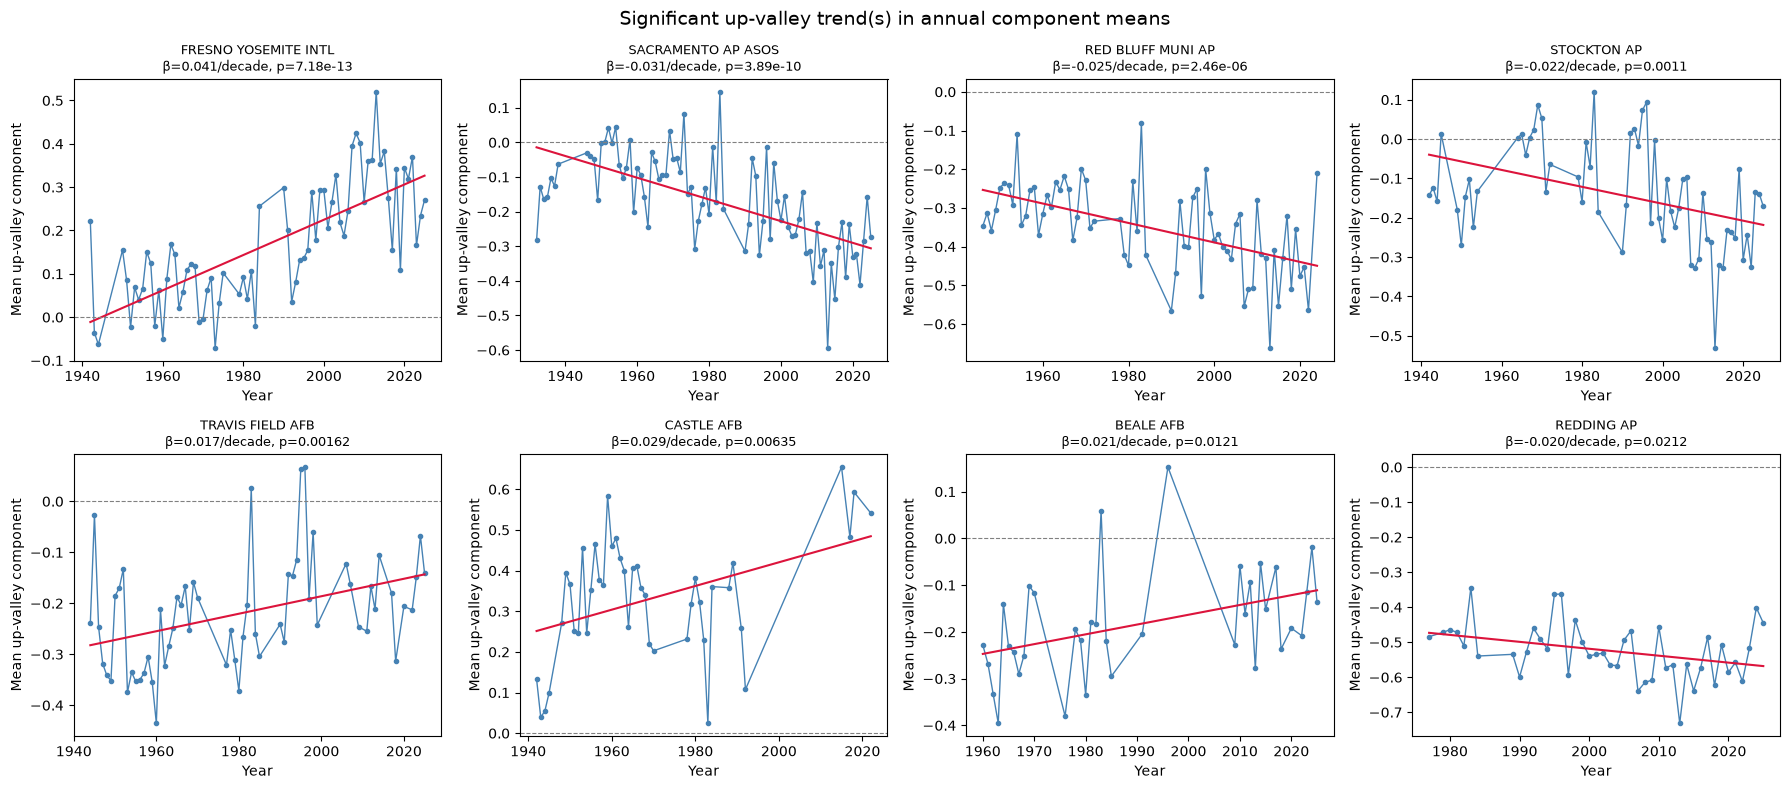

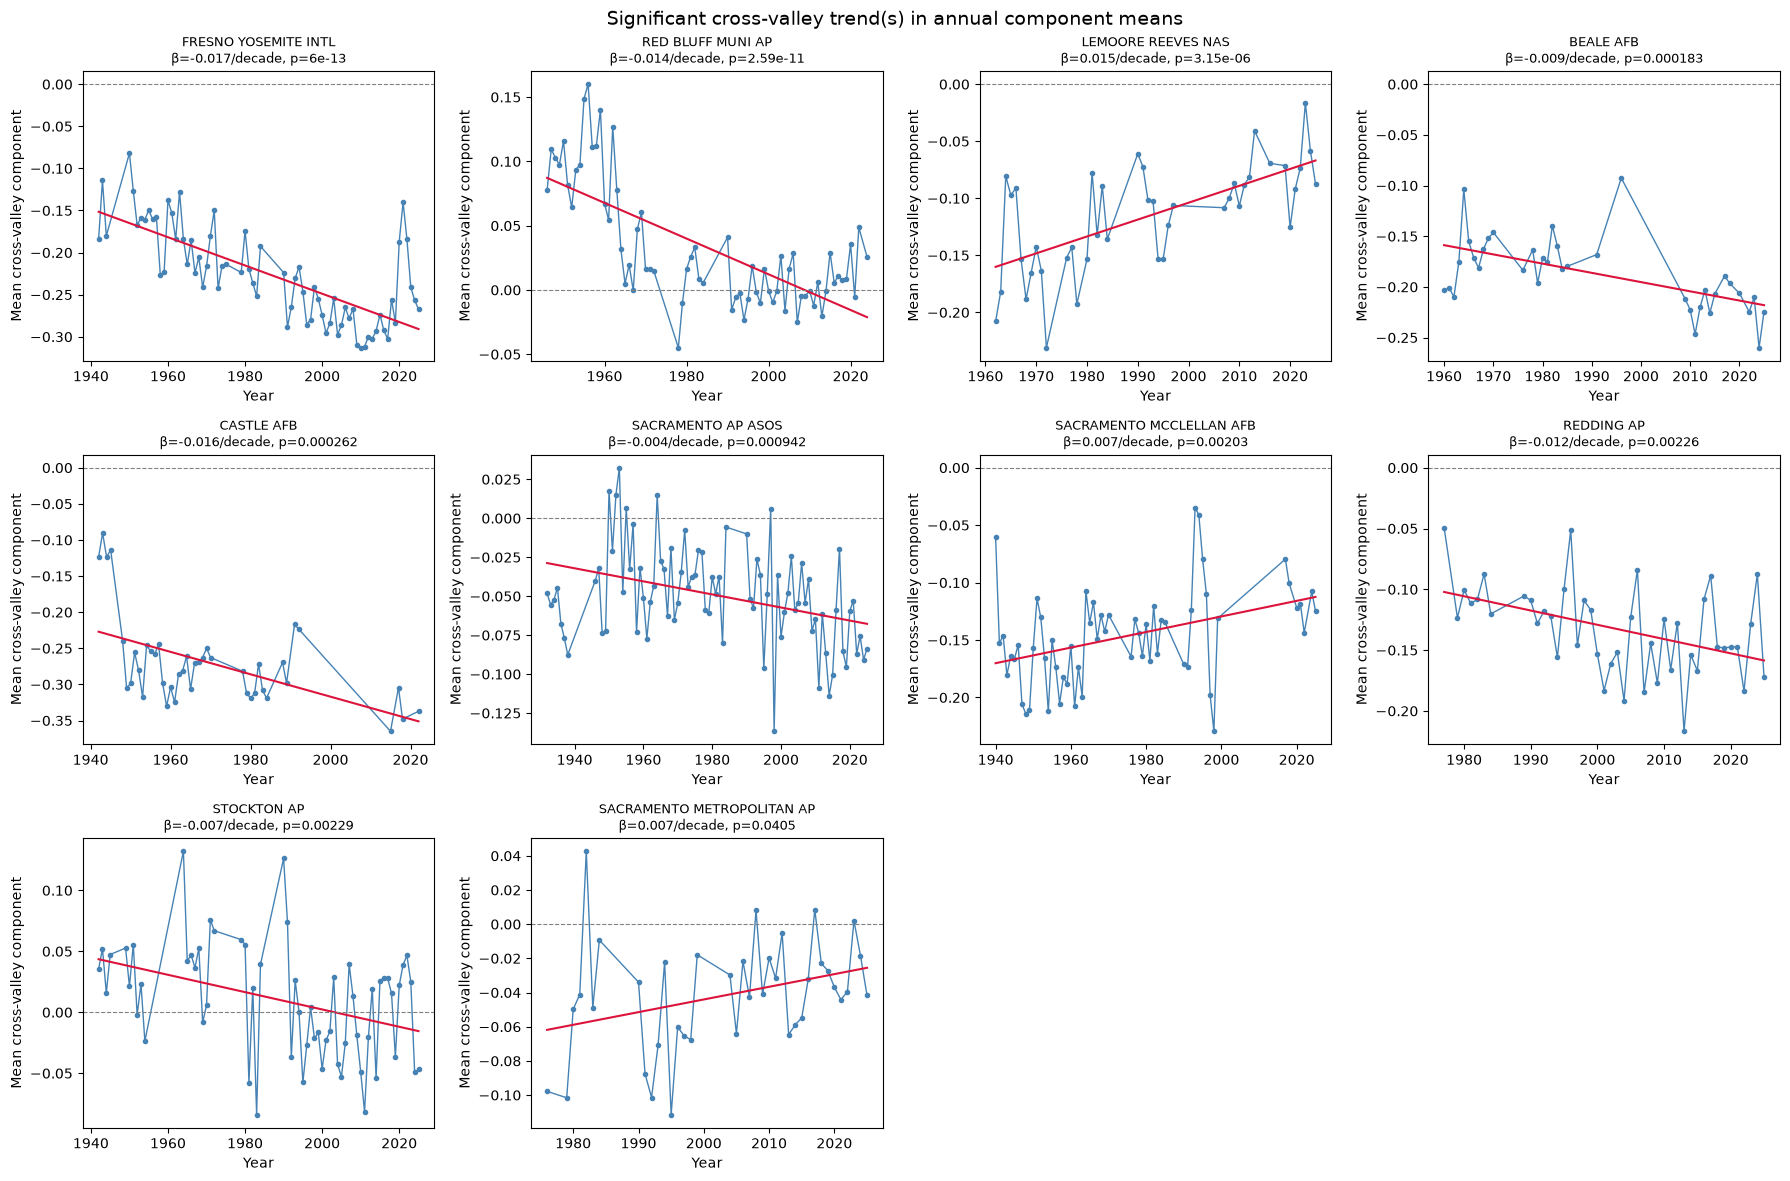

In [18]:
# Annual average up-valley and cross-valley components by station and year
# Use the existing raw station-year wind-direction table if available
if "annual_wind_dir" not in globals():
    annual_wind_dir = annual_avg_wind_dir.copy()

annual_components = (
    annual_wind_dir
    .groupby(["STATION", "year"], as_index=False)
    .agg(
        mean_up_valley_component=("up_valley_cos", "mean"),
        mean_cross_valley_component=("cross_valley_cos", "mean"),
        n_obs=("up_valley_cos", "size"),
    )
    .sort_values(["STATION", "year"])
)

# Fit linear trends for each station/component
trend_rows = []

for station, g in annual_components.groupby("STATION"):
    for col, component in [
        ("mean_up_valley_component", "up_valley"),
        ("mean_cross_valley_component", "cross_valley"),
    ]:
        d = g[["year", col]].dropna()

        if d["year"].nunique() < 10 or d[col].nunique() < 2:
            continue

        fit = stats.linregress(d["year"].to_numpy(), d[col].to_numpy())

        trend_rows.append({
            "STATION": station,
            "component": component,
            "start_year": int(d["year"].min()),
            "end_year": int(d["year"].max()),
            "n_years": int(d["year"].nunique()),
            "slope_per_year": fit.slope,
            "slope_per_decade": fit.slope * 10,
            "intercept": fit.intercept,
            "r_squared": fit.rvalue ** 2,
            "p_value": fit.pvalue,
        })

trend_df = pd.DataFrame(trend_rows)
sig_trends = trend_df[trend_df["p_value"] < 0.05].copy()

print(f"Total station-component trends tested: {len(trend_df)}")
print(f"Significant trends (p < 0.05): {len(sig_trends)}")
display(sig_trends.sort_values(["component", "p_value"]).reset_index(drop=True))

# Plot only significant trends
for comp_name, value_col, ylab in [
    ("up_valley", "mean_up_valley_component", "Mean up-valley component"),
    ("cross_valley", "mean_cross_valley_component", "Mean cross-valley component"),
]:
    sig_comp = sig_trends[sig_trends["component"] == comp_name].sort_values("p_value")

    if sig_comp.empty:
        print(f"No significant {comp_name.replace('_', '-')} trends found.")
        continue

    ncols = 4
    nrows = int(np.ceil(len(sig_comp) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows), squeeze=False)
    axes = axes.ravel()

    for ax, (_, result) in zip(axes, sig_comp.iterrows()):
        d = annual_components[
            annual_components["STATION"] == result["STATION"]
        ][["year", value_col]].dropna().sort_values("year")

        if d.empty:
            continue

        # Use a trend line based on the fitted slope and intercept
        fitted = result["intercept"] + result["slope_per_year"] * d["year"]

        ax.plot(d["year"], d[value_col], marker="o", markersize=3, linewidth=1, color="steelblue")
        ax.plot(d["year"], fitted, color="crimson", linewidth=1.5)
        ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)

        ax.set_title(
            f"{result['STATION']}\n"
            f"β={result['slope_per_decade']:.3f}/decade, p={result['p_value']:.3g}",
            fontsize=9,
        )
        ax.set_xlabel("Year")
        ax.set_ylabel(ylab)

    for ax in axes[len(sig_comp):]:
        ax.remove()

    fig.suptitle(f"Significant {comp_name.replace('_', '-')} trend(s) in annual component means", fontsize=14)
    plt.tight_layout()
    plt.show()

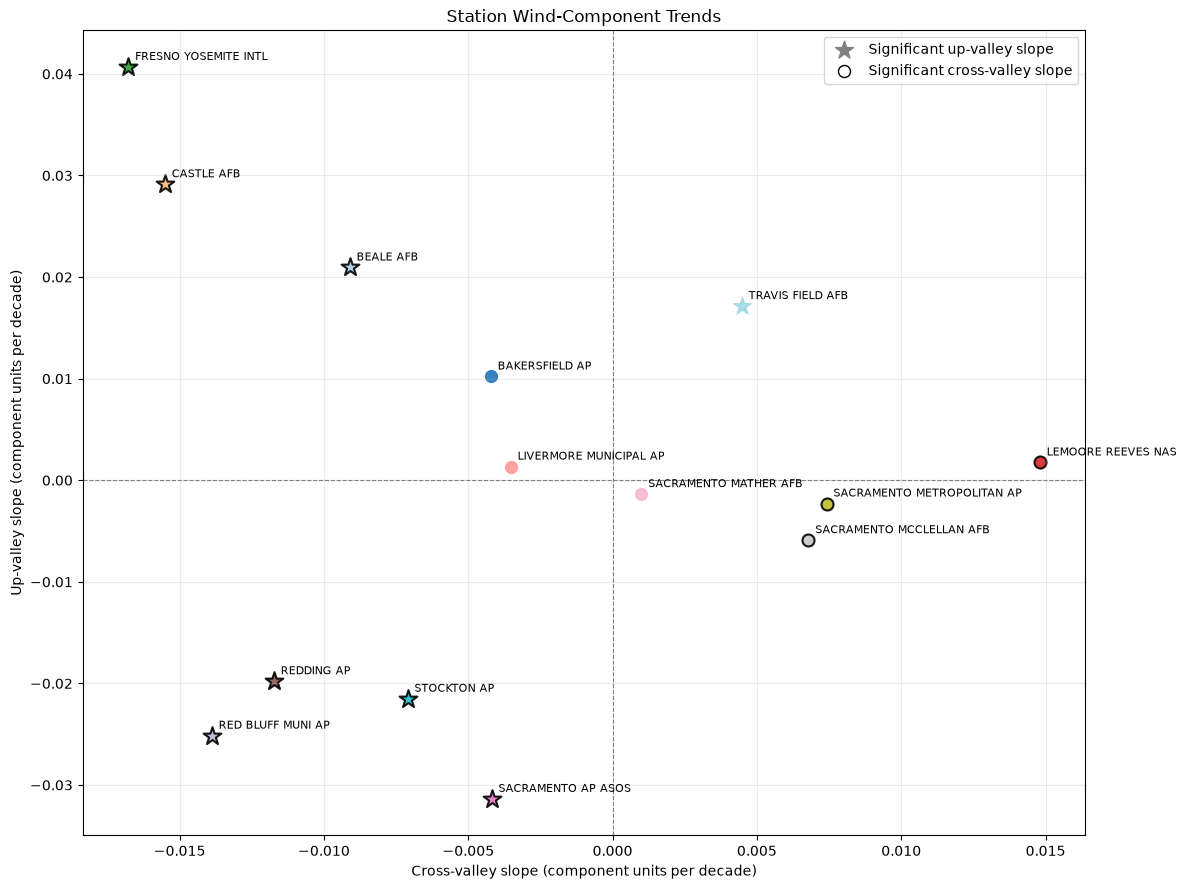

In [19]:
# Plot station trend slopes:
# x-axis = cross-valley slope, y-axis = up-valley slope.
# Significant up-valley trends use star markers.
# Significant cross-valley trends have black outlines.

slope_data = (
    trend_df
    .pivot(index="STATION", columns="component", values=["slope_per_decade", "p_value"])
    .dropna()
)

slope_data.columns = [
    f"{metric}_{component}"
    for metric, component in slope_data.columns
]

stations = slope_data.index.tolist()
colors = plt.cm.tab20(np.linspace(0, 1, len(stations)))

fig, ax = plt.subplots(figsize=(12, 9))

for station, color in zip(stations, colors):
    row = slope_data.loc[station]

    cross_slope = row["slope_per_decade_cross_valley"]
    up_slope = row["slope_per_decade_up_valley"]

    significant_cross = row["p_value_cross_valley"] < 0.05
    significant_up = row["p_value_up_valley"] < 0.05

    ax.scatter(
        cross_slope,
        up_slope,
        color=color,
        marker="*" if significant_up else "o",
        s=180 if significant_up else 75,
        edgecolors="black" if significant_cross else color,
        linewidths=1.5 if significant_cross else 0.8,
        alpha=0.9,
    )

    ax.annotate(
        station,
        (cross_slope, up_slope),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

# Reference axes
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)

# Legend for significance styles
ax.scatter(
    [], [], color="gray", marker="*", s=180,
    label="Significant up-valley slope"
)
ax.scatter(
    [], [], color="white", edgecolors="black", s=75,
    label="Significant cross-valley slope"
)

ax.set_xlabel("Cross-valley slope (component units per decade)")
ax.set_ylabel("Up-valley slope (component units per decade)")
ax.set_title("Station Wind-Component Trends")
ax.grid(True, alpha=0.25)
ax.legend(loc="best")

plt.tight_layout()
plt.show()

,STATION,year,mean_up_valley_component,mean_cross_valley_component,n_obs
0,BAKERSFIELD AP,1980,0.236771,-0.263778,3644
1,BAKERSFIELD AP,1981,0.263388,-0.231481,3622
2,BAKERSFIELD AP,1982,0.186204,-0.165493,3621
3,BAKERSFIELD AP,1983,0.099842,-0.186376,3618
4,BAKERSFIELD AP,1984,0.171552,-0.148071,3630
...,...,...,...,...,...
443,TRAVIS FIELD AFB,2020,-0.201745,0.039292,3550
444,TRAVIS FIELD AFB,2022,-0.209739,0.053382,3490
445,TRAVIS FIELD AFB,2023,-0.146421,-0.036228,3454
446,TRAVIS FIELD AFB,2024,-0.065851,0.074778,3558


,STATION,component,start_year,end_year,n_years,slope_per_year,slope_per_decade,intercept,r_squared,p_value
1,BAKERSFIELD AP,cross_valley,1980,2025,41,-0.002977,-0.029775,5.694503,0.474883,6.299035e-07
3,BEALE AFB,cross_valley,1980,2025,22,-0.001550,-0.015505,2.917542,0.477264,3.714064e-04
17,SACRAMENTO AP ASOS,cross_valley,1980,2025,41,-0.001020,-0.010200,1.985659,0.191180,4.255444e-03
9,LEMOORE REEVES NAS,cross_valley,1980,2025,28,0.001091,0.010911,-2.279534,0.252199,6.465756e-03
15,REDDING AP,cross_valley,1980,2025,42,-0.001091,-0.010908,2.056181,0.168383,6.952808e-03
27,TRAVIS FIELD AFB,cross_valley,1980,2025,30,0.001753,0.017534,-3.491146,0.132203,4.826023e-02
0,BAKERSFIELD AP,up_valley,1980,2025,41,0.004137,0.041375,-8.010273,0.461176,1.055057e-06
16,SACRAMENTO AP ASOS,up_valley,1980,2025,41,-0.005791,-0.057906,11.367941,0.329827,8.623748e-05
6,FRESNO YOSEMITE INTL,up_valley,1980,2025,41,0.005116,0.051165,-10.011659,0.309713,1.577917e-04
24,STOCKTON AP,up_valley,1980,2025,41,-0.005343,-0.053431,10.539937,0.261320,6.364901e-04


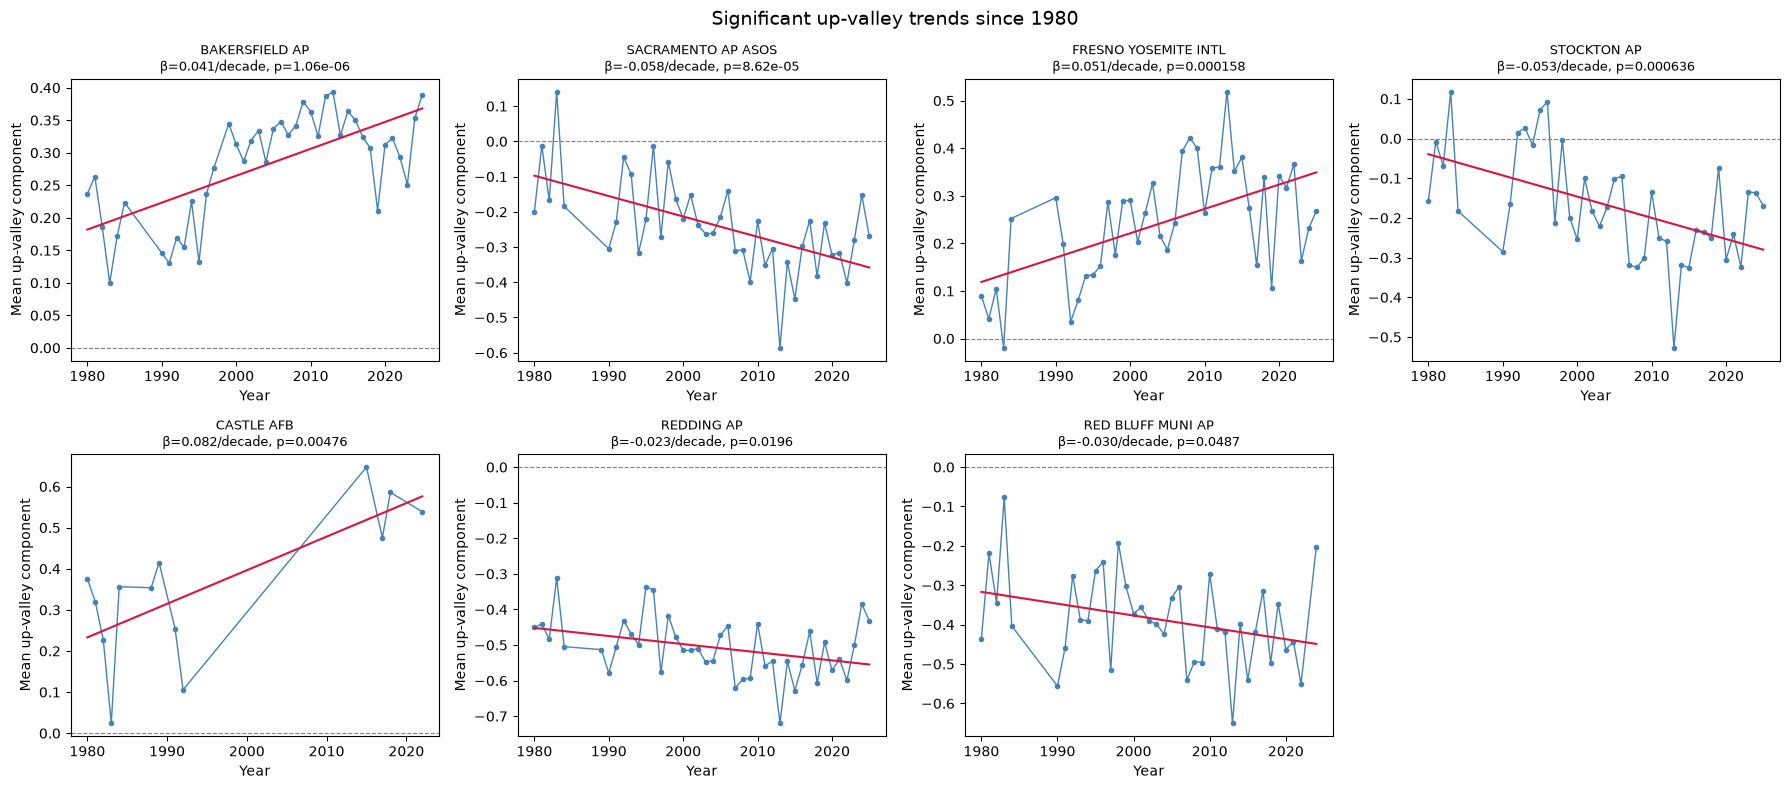

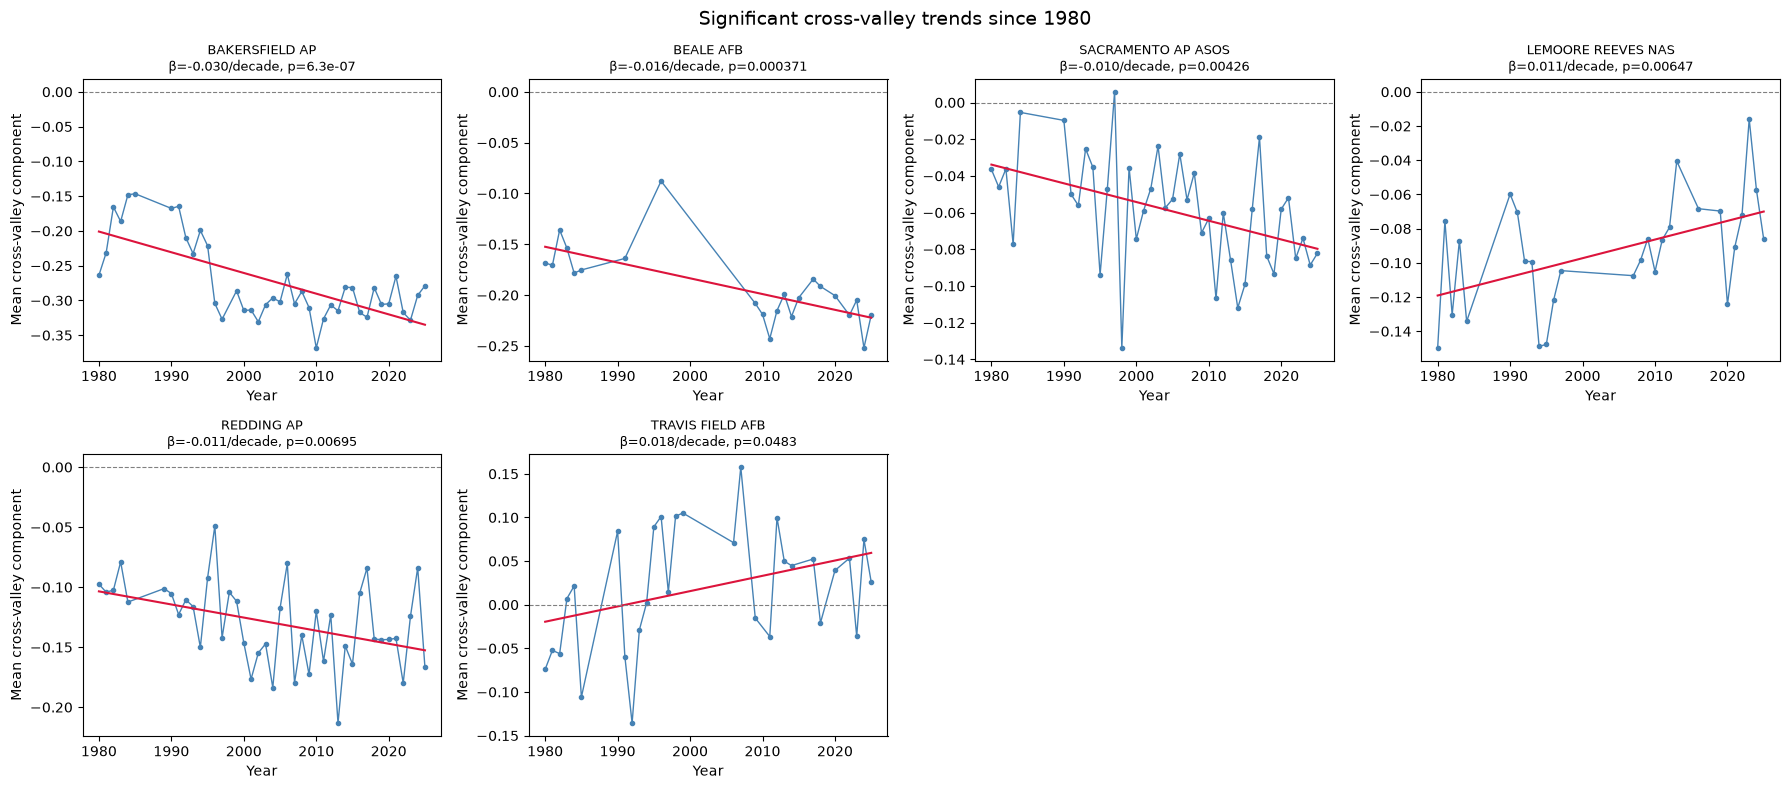

In [20]:
# Repeat the annual component analysis for station-years from 1980 onward

annual_components_1980 = (
    CV_filtered_rows.loc[CV_filtered_rows["year"] >= 1980]
    .groupby(["STATION", "year"], as_index=False)
    .agg(
        mean_up_valley_component=("up_valley_component", "mean"),
        mean_cross_valley_component=("cross_valley_component", "mean"),
        n_obs=("up_valley_component", "count"),
    )
    .sort_values(["STATION", "year"])
)

trend_rows_1980 = []

for station, group in annual_components_1980.groupby("STATION"):
    for value_col, component_name in [
        ("mean_up_valley_component", "up_valley"),
        ("mean_cross_valley_component", "cross_valley"),
    ]:
        data = group[["year", value_col]].dropna()

        if data["year"].nunique() < 10 or data[value_col].nunique() < 2:
            continue

        fit = stats.linregress(data["year"], data[value_col])

        trend_rows_1980.append({
            "STATION": station,
            "component": component_name,
            "start_year": int(data["year"].min()),
            "end_year": int(data["year"].max()),
            "n_years": int(data["year"].nunique()),
            "slope_per_year": fit.slope,
            "slope_per_decade": fit.slope * 10,
            "intercept": fit.intercept,
            "r_squared": fit.rvalue ** 2,
            "p_value": fit.pvalue,
        })

trend_df_1980 = pd.DataFrame(trend_rows_1980)
sig_trends_1980 = trend_df_1980[trend_df_1980["p_value"] < 0.05].copy()

display(annual_components_1980)
display(sig_trends_1980.sort_values(["component", "p_value"]))

# Plot significant trends
for component_name, value_col, ylabel in [
    ("up_valley", "mean_up_valley_component", "Mean up-valley component"),
    ("cross_valley", "mean_cross_valley_component", "Mean cross-valley component"),
]:
    significant = (
        sig_trends_1980[sig_trends_1980["component"] == component_name]
        .sort_values("p_value")
    )

    if significant.empty:
        print(f"No significant {component_name.replace('_', '-')} trends found.")
        continue

    ncols = 4
    nrows = int(np.ceil(len(significant) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(18, 4 * nrows), squeeze=False
    )
    axes = axes.ravel()

    for ax, (_, result) in zip(axes, significant.iterrows()):
        data = (
            annual_components_1980[
                annual_components_1980["STATION"] == result["STATION"]
            ][["year", value_col]]
            .dropna()
            .sort_values("year")
        )

        fitted = (
            result["intercept"]
            + result["slope_per_year"] * data["year"]
        )

        ax.plot(
            data["year"], data[value_col],
            marker="o", markersize=3, linewidth=1,
            color="steelblue"
        )
        ax.plot(data["year"], fitted, color="crimson", linewidth=1.5)
        ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)

        ax.set_title(
            f"{result['STATION']}\n"
            f"β={result['slope_per_decade']:.3f}/decade, "
            f"p={result['p_value']:.3g}",
            fontsize=9,
        )
        ax.set_xlabel("Year")
        ax.set_ylabel(ylabel)

    for ax in axes[len(significant):]:
        ax.remove()

    fig.suptitle(
        f"Significant {component_name.replace('_', '-')} trends since 1980",
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()

In [21]:
# # Plot station wind-component trends since 1980:
# # x-axis = cross-valley slope, y-axis = up-valley slope

# # get slope data for regression from 1980 onwards
# slope_data_1980 = (
#     trend_df_1980
#     .pivot(index="STATION", columns="component", values=["slope_per_decade", "p_value"])
#     .dropna()
# )

# # Flatten the multi-index columns for easier access, meaning
# # each column will be named as "metric_component"
# slope_data_1980.columns = [
#     f"{metric}_{component}"
#     for metric, component in slope_data_1980.columns
# ]

# # Attach latitude for coloring
# station_lat = (
#     CV_filtered_rows.groupby("STATION", as_index=False)["LATITUDE"]
#     .median()
#     .rename(columns={"LATITUDE": "latitude"})
# )
# slope_data_1980 = slope_data_1980.merge(station_lat, on="STATION", how="left").dropna(subset=["latitude"])

# # Prepare colors for plotting based on latitude
# colors = plt.cm.tab20(np.linspace(0, 1, len(slope_data_1980)))

# # Map station to latitude for coloring
# station_to_lat = station_lat.set_index("STATION")["latitude"].to_dict()

# # Create the plot for station wind-component trends
# fig, ax = plt.subplots(figsize=(12, 9))

# # Plot each station's wind-component trend as a scatter point, colored by latitude
# # Make sure to keep the names of stations
# for (station, row), color in zip(slope_data_1980.iterrows(), colors):
#     color = plt.cm.coolwarm_r((row["latitude"] - slope_data_1980["latitude"].min()) / (slope_data_1980["latitude"].max() - slope_data_1980["latitude"].min()))
#     cross_slope = row["slope_per_decade_cross_valley"]
#     up_slope = row["slope_per_decade_up_valley"]

# # Determine if the trends are statistically significant
#     significant_cross = row["p_value_cross_valley"] < 0.05
#     significant_up = row["p_value_up_valley"] < 0.05

# # Plot the scatter point 
#     ax.scatter(
#         # x-coordinate: cross-valley slope, y-coordinate: up-valley slope
#         cross_slope,
#         up_slope,
#         # color based on latitude
#         color=color,
#         # marker and size indicate statistical significance
#         marker="*" if significant_up else "o",
#         # edge color and linewidth indicate statistical significance of cross-valley trend
#         s=180 if significant_up else 75,
#         # alpha controls the transparency of the point
#         edgecolors="black" if significant_cross else color,
#         # linewidth controls the thickness of the point's edge
#         linewidths=1.5 if significant_cross else 0.8,
#         # alpha controls the transparency of the point
#         alpha=0.9,
#     )

# # Annotate the station name next to the scatter point
#     ax.annotate(
#         # text to display (station name). Keep the station name instead of a number
#         # CV_filtered_rows["STATION"],
#         station,
#         # position to place the annotation (next to the scatter point)
#         (cross_slope, up_slope),
#         # offset for the annotation text
#         xytext=(5, 5),
#         # specify that the offset is in points relative to the scatter point
#         textcoords="offset points",
#         # font size of the annotation text
#         fontsize=8,
#     )


# ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
# ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)

# ax.scatter(
#     [], [], color="gray", marker="*", s=180,
#     label="Significant up-valley trend"
# )
# ax.scatter(
#     [], [], color="white", edgecolors="black", s=75,
#     label="Significant cross-valley trend"
# )

# ax.set_xlabel("Cross-valley slope (component units per decade)")
# ax.set_ylabel("Up-valley slope (component units per decade)")
# ax.set_title("Station Wind-Component Trends Since 1980")
# ax.grid(True, alpha=0.25)
# ax.legend(loc="best")

# plt.tight_layout()
# plt.show()

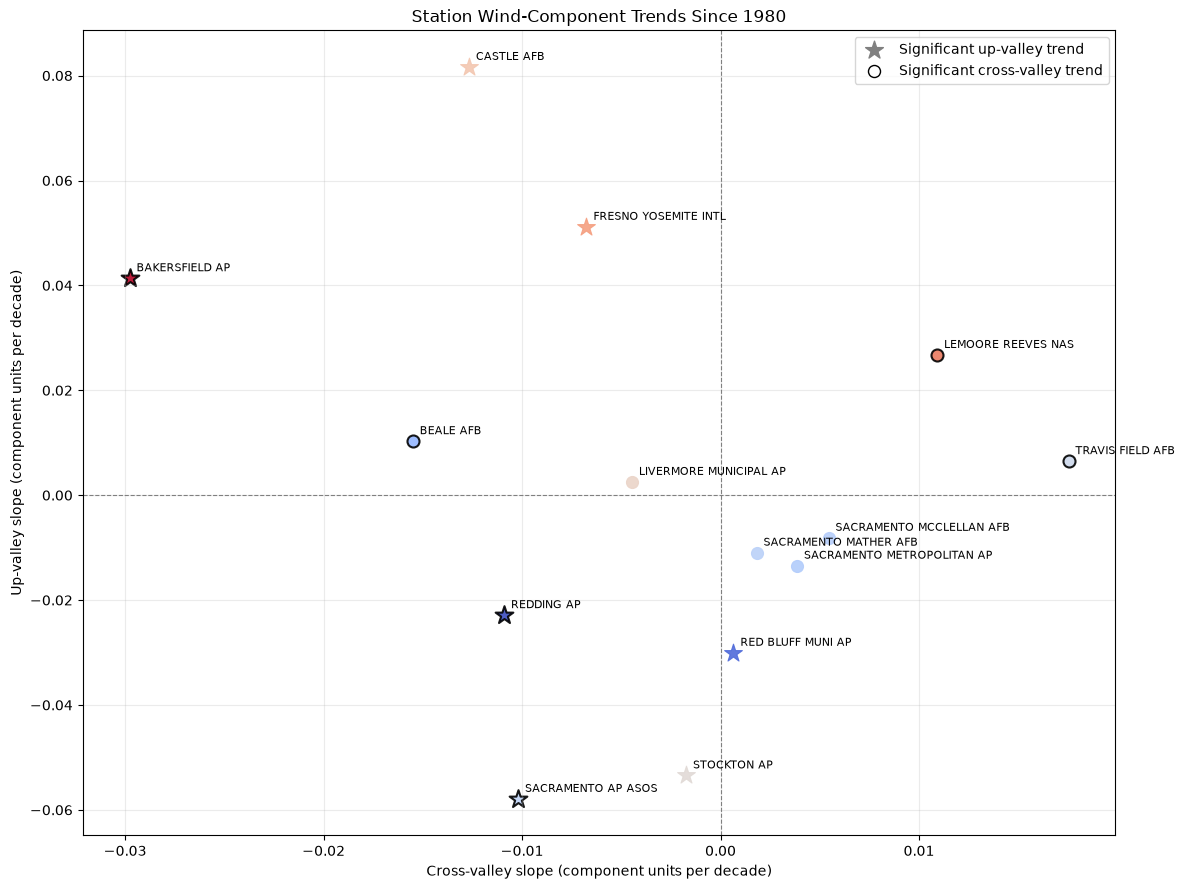

In [28]:
# Recreate the station trend plot with station names as point labels

slope_data_1980 = (
    trend_df_1980
    .pivot(index="STATION", columns="component", values=["slope_per_decade", "p_value"])
    .dropna()
)

# Flatten the multi-index columns for easier access, meaning
# each column will be named as "metric_component"
slope_data_1980.columns = [
    f"{metric}_{component}"
    for metric, component in slope_data_1980.columns
]

# Attach latitude for coloring
station_lat = (
    CV_filtered_rows.groupby("STATION", as_index=False)["LATITUDE"]
    .median()
    .rename(columns={"LATITUDE": "latitude"})
)

plot_data = slope_data_1980.merge(station_lat, on="STATION", how="left").dropna(subset=["latitude"])

lat_min = plot_data["latitude"].min()
lat_max = plot_data["latitude"].max()
lat_range = lat_max - lat_min if lat_max != lat_min else 1

fig, ax = plt.subplots(figsize=(12, 9))

for _, row in plot_data.iterrows():
    station = row["STATION"]
    color = plt.cm.coolwarm_r((row["latitude"] - lat_min) / lat_range)

    significant_cross = row["p_value_cross_valley"] < 0.05
    significant_up = row["p_value_up_valley"] < 0.05

    ax.scatter(
        row["slope_per_decade_cross_valley"],
        row["slope_per_decade_up_valley"],
        color=color,
        marker="*" if significant_up else "o",
        s=180 if significant_up else 75,
        edgecolors="black" if significant_cross else color,
        linewidths=1.5 if significant_cross else 0.8,
        alpha=0.9,
    )

    ax.annotate(
        station,
        (
            row["slope_per_decade_cross_valley"],
            row["slope_per_decade_up_valley"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)

ax.scatter([], [], color="gray", marker="*", s=180,
           label="Significant up-valley trend")
ax.scatter([], [], color="white", edgecolors="black", s=75,
           label="Significant cross-valley trend")

ax.set_xlabel("Cross-valley slope (component units per decade)")
ax.set_ylabel("Up-valley slope (component units per decade)")
ax.set_title("Station Wind-Component Trends Since 1980")
ax.grid(True, alpha=0.25)
ax.legend(loc="best")

plt.tight_layout()
plt.show()

In [ ]:
# Remove station-years with fewer than 7 observations
for df_name in ["annual_wind_components", "annual_components", "annual_avg_wind_dir"]:
    if df_name in globals():
        df = globals()[df_name]
        if "n_obs" in df.columns:
            globals()[df_name] = df[df["n_obs"] >= 7].copy()
        elif "n_observations" in df.columns:
            globals()[df_name] = df[df["n_observations"] >= 7].copy()

print("annual_wind_components shape:", annual_wind_components.shape if "annual_wind_components" in globals() else "not defined")
print("annual_components shape:", annual_components.shape if "annual_components" in globals() else "not defined")
print("annual_avg_wind_dir shape:", annual_avg_wind_dir.shape if "annual_avg_wind_dir" in globals() else "not defined")

annual_wind_components shape: (767, 7)
annual_components shape: (767, 5)
annual_avg_wind_dir shape: (767, 11)
